# Tugas Supervised Learning: Decision Tree dan Support Vector Machine untuk Multi-Class Classification

**Mata kuliah:** Analitik Data  
**Topik:** Supervised Learning — Decision Tree dan Support Vector Machine  
**Fokus utama revisi:** Pembentukan Decision Tree menggunakan **Entropy** dan **Information Gain** secara manual, dilanjutkan dengan implementasi dan analisis model.

## Tujuan
Setelah menyelesaikan notebook ini, mahasiswa mampu:
1. Menghasilkan dataset multi-class dan melakukan eksplorasi data.
2. Menjelaskan dan menghitung **Entropy** dan **Information Gain** untuk pembentukan Decision Tree.
3. Menentukan **root node** dan mensimulasikan minimal **dua level tree** secara manual.
4. Mengimplementasikan Decision Tree dan SVM untuk multi-class classification.
5. Membandingkan Decision Tree, SVM Linear, dan SVM RBF melalui metrik evaluasi dan visualisasi decision boundary.
6. Menyusun analisis kritis berbasis hasil eksperimen.

## Aturan
- Semua sel wajib dijalankan berurutan.
- Isi bagian jawaban analisis pada markdown yang tersedia.
- Gunakan model yang diminta: `DecisionTreeClassifier` dan `SVC`.
- Wajib mengisi deklarasi penggunaan AI.


## 0. Identitas dan Deklarasi Penggunaan AI

Isi informasi berikut sebelum menjalankan validasi akhir.

- Nama: Aliya Harta Ary Utama
- NIM: 18223081
- Kelas: K01

### Deklarasi penggunaan AI
Jelaskan apakah Anda menggunakan AI generatif. Jika ya, sebutkan untuk bagian apa, bagaimana Anda memverifikasi hasilnya, dan bagian mana yang merupakan analisis mandiri Anda.

Penggunaan AI


In [ ]:
# ===== WAJIB DIISI =====
NAMA = "Aliya Harta Ary Utama"
NIM = "18223081"
KELAS = "K01"

DEKLARASI_AI = """
Saya menggunakan AI untuk membantu memahami konsep cara kerja algoritma DT seperti interpretasi matematis dari Information Gain, Entropy pada Decision Tree serta proyeksi dimensi tinggi pada kernel RBF di Support Vector Machine (SVM). Seluruh logika yang dihasilkan telah saya verifikasi kembali dengan materi perkuliahan.
"""

assert NAMA.strip() != "", "Nama belum diisi."
assert NIM.strip() != "", "NIM belum diisi."
assert KELAS.strip() != "", "Kelas belum diisi."
assert len(DEKLARASI_AI.strip()) >= 80, "Deklarasi penggunaan AI terlalu singkat."
print("Identitas dan deklarasi AI terisi.")

Identitas dan deklarasi AI terisi.


## 1. Setup Library dan Reproducibility

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 6)
print("Library berhasil dimuat.")

Library berhasil dimuat.


## 2. Dataset Multi-Class

Dataset dibuat langsung di notebook agar tidak memerlukan pengaturan path. Dataset ini sengaja memiliki:
- fitur yang cukup baik untuk pemisahan berbasis threshold,
- fitur dengan pola non-linear,
- fitur noise,
- fitur redundant.

Kondisi ini membantu memperlihatkan keunggulan dan kelemahan Decision Tree serta SVM.


In [24]:
# ===== Dataset generator =====
n_samples = 600

# Komponen fitur threshold-friendly: empat klaster
X_blob, y_blob = make_blobs(
    n_samples=n_samples,
    centers=[(-4, -4), (-4, 4), (4, -4), (4, 4)],
    cluster_std=[1.2, 1.3, 1.1, 1.4],
    random_state=RANDOM_STATE
)

# Komponen fitur non-linear: pola radial/gelombang yang tidak menjadi label utama,
# tetapi memberikan informasi parsial bagi model non-linear.
rng = np.random.default_rng(RANDOM_STATE)
angle = rng.uniform(0, 2*np.pi, n_samples)
radius = 1.2 + (y_blob * 0.55) + rng.normal(0, 0.35, n_samples)
feature_3 = radius * np.cos(angle) + rng.normal(0, 0.15, n_samples)
feature_4 = radius * np.sin(angle) + rng.normal(0, 0.15, n_samples)

# Noise dan redundant feature
feature_5_noise = rng.normal(0, 2.5, n_samples)
feature_6_redundant = 0.65 * X_blob[:, 0] - 0.25 * X_blob[:, 1] + rng.normal(0, 0.7, n_samples)

X = np.column_stack([
    X_blob[:, 0], X_blob[:, 1],
    feature_3, feature_4,
    feature_5_noise, feature_6_redundant
])

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(1, 7)])
df["target"] = y_blob.astype(int)

df.to_csv("dataset_dt_svm_multiclass.csv", index=False)

print(df.shape)
display(df.head())
display(df["target"].value_counts().sort_index())

(600, 7)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,target
0,-3.708680,4.016370,0.350208,-2.130457,-1.747555,-3.502265,1
1,3.972507,4.773486,-2.505529,0.866474,0.106578,0.961689,3
2,-5.063687,6.720103,1.246410,-1.237546,-0.216762,-3.361657,1
3,5.100120,4.595641,-0.849596,-1.776427,-0.684260,2.103356,3
4,-4.323653,5.263042,1.244750,0.764713,1.975851,-3.044473,1


target
0    150
1    150
2    150
3    150
Name: count, dtype: int64

## 3. Exploratory Data Analysis

Lakukan eksplorasi awal dan jawab pertanyaan:
1. Apakah setiap kelas tampak terpisah sempurna?
2. Fitur mana yang tampak paling informatif?
3. Apakah ada fitur yang tampak noisy?


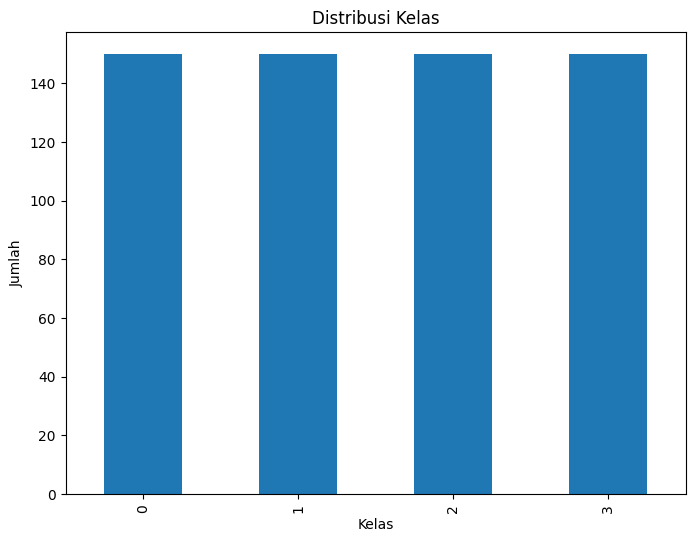

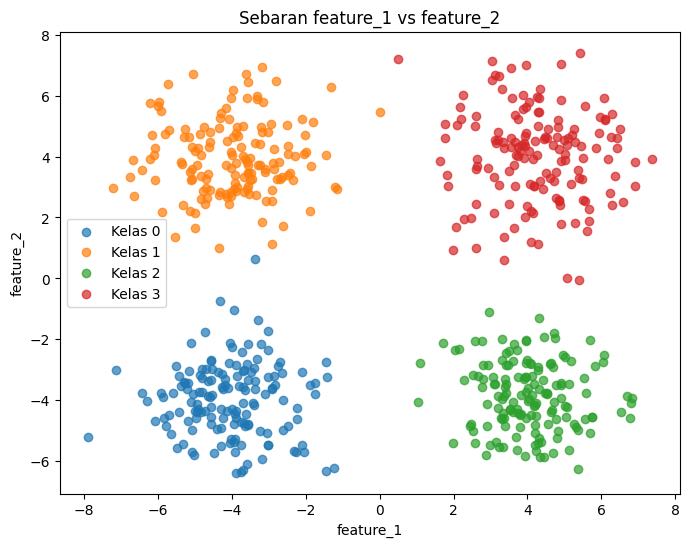

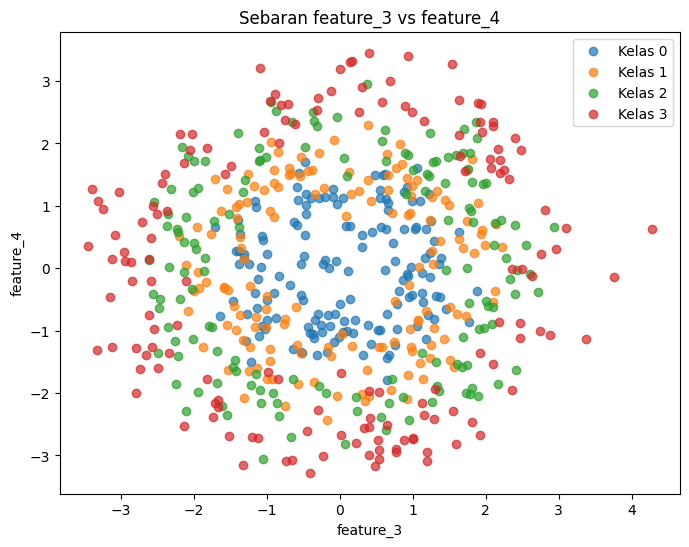

In [25]:
# Distribusi kelas
class_counts = df["target"].value_counts().sort_index()
ax = class_counts.plot(kind="bar")
ax.set_title("Distribusi Kelas")
ax.set_xlabel("Kelas")
ax.set_ylabel("Jumlah")
plt.show()

# Scatter fitur utama
plt.figure()
for cls in sorted(df["target"].unique()):
    subset = df[df["target"] == cls]
    plt.scatter(subset["feature_1"], subset["feature_2"], label=f"Kelas {cls}", alpha=0.7)
plt.title("Sebaran feature_1 vs feature_2")
plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.legend()
plt.show()

plt.figure()
for cls in sorted(df["target"].unique()):
    subset = df[df["target"] == cls]
    plt.scatter(subset["feature_3"], subset["feature_4"], label=f"Kelas {cls}", alpha=0.7)
plt.title("Sebaran feature_3 vs feature_4")
plt.xlabel("feature_3")
plt.ylabel("feature_4")
plt.legend()
plt.show()

### Jawaban Analisis EDA

Tuliskan minimal 1 paragraf:
1. Apakah setiap kelas tampak terpisah sempurna?
2. Fitur mana yang tampak paling informatif?
3. Apakah ada fitur yang tampak noisy?

- fitur yang paling memisahkan kelas,
- indikasi noise/overlap,
- implikasi awal terhadap Decision Tree dan SVM.

**Jawaban:**  
Berdasarkan hasil EDA diatas, terlihat bahwa : 
1. Plot untuk feature_1 dan feature_2 menghasilkan pemisahan kelas yang sempurna, tidak ada yang saling overlap, serta batas antar kelas sangat terlihat jelas. Namun, jika dilihat plot dari feature_3 dan feature_4 terlihat bahwa sebaran kelas overlap satu sama lain, dimana data menyebar dalam bentuk pola lingkaran di mana batas antar kelasnya memiliki overlap yang cukup signifikan.
2. Fitur yang paling informatif adalah feature_1 dan feature_2, karena batas antar kelas terlihat sangat jelas, sehingga jika menggunakan algoritma akan dengan sangat mudah menentukan keputusan kelas target.
3. Jika dilihat dari 2 plot diatas, kita bisa mengetahui bahwa feature_3 dan feature_4 tersebar dengan pola lingkaran, dan batas antar kelas tidak terlihat jelas, karena saling overlapping satu sama lain, dimana nilai feature_4 menumpuk pada nilai -3 hingga 3. Namun, juga terdapat beberapa titik dari kelas 1, 2, 3 yang berbaur di batas-batas lingkaran tersebut.
4. Distribusi kelas target terlihat seimbang untuk kelas 0 - 3 dengan 150 data, sehingga memastikan model tidak akan bias terhadap kelas mayoritas. 
- Jika terlihat dari kekuatan Decision Tree, dia bekerja dengan axis-aligned splits, yang sangat cocok untuk memisahkan empat cluster kotak tersebut hanya dengan beberapa depth, sehingga menurut teori decision tree akan bekerja dengan sangat efisien dan akurat pada feature_1 dan feature_2, namun jiks Decision Tree digunakan pada feature_3 dan feature_4, hal ini bisa menyebabkan resiko overfitting pada model, karena seperti yang kita tahu bahwa model memiliki pola lingkaran, dimana kekuatan Decision Tree yaitu axis-aligned splits, akan membuat seperti kurva yang beresiko overfitting. 
- Namun, pada algoritma SVM Linear akan berhasil dalam pemisahan kelas dengan feature_1 dan feature_2 karena sebaran kelas tersebut linearly separable, namun akan gagal jika diterapkan pada feature_3 dan feature_4 karena tidak linearly separable. Selanjutnya jika algoritma SVM RBF secara teori dapat memisahkan klaster linear di feature_1 dan feature_2, sekaligus mampu menarik batas keputusan berbentuk kurva melingkar tertutup, yang sangat sempurna untuk menyelesaikan pola lingkaran pada feature_3 dan feature_4.

# 4. Fokus Utama: Pembentukan Decision Tree Manual dengan Entropy dan Information Gain

Bagian ini merupakan komponen utama penilaian. Anda tidak cukup hanya menggunakan `DecisionTreeClassifier`; Anda harus menunjukkan bagaimana tree terbentuk melalui proses matematis.


## 4.1 Subset Data untuk Perhitungan Manual

Gunakan 20 baris sampel agar perhitungan manual dapat ditelusuri. Untuk memudahkan perhitungan, fitur numerik akan didiskritisasi dengan threshold berbasis median/mean.


In [26]:
df_sample = df.sample(20, random_state=RANDOM_STATE).copy()
df_sample_manual = df_sample[["feature_1", "feature_2", "target"]].reset_index(drop=True)

print("Subset data untuk perhitungan manual:")
display(df_sample_manual)

manual_calculation_done = False
root_node_selected = False
level2_simulation_done = False

Subset data untuk perhitungan manual:


,feature_1,feature_2,target
0,1.864265,3.031329,3
1,-5.016152,-5.817817,0
2,-4.816030,-3.721296,0
3,-3.113461,3.596653,1
4,-3.883507,-2.837626,0
5,-4.585085,4.809705,1
6,2.451737,-4.855598,2
7,-1.153256,2.949212,1
8,4.281633,-2.919040,2
9,4.691642,4.364943,3


## 4.2 Fungsi Entropy dan Information Gain

Lengkapi dan jalankan fungsi berikut. Fungsi ini boleh digunakan untuk membantu perhitungan, tetapi Anda tetap wajib menjelaskan langkahnya secara tertulis.


In [27]:
def entropy(y):
    """Hitung entropy dari array label kelas."""
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

def information_gain_for_threshold(data, feature, target_col, threshold):
    """Hitung Information Gain untuk split biner feature <= threshold vs > threshold."""
    parent_entropy = entropy(data[target_col].values)

    left = data[data[feature] <= threshold]
    right = data[data[feature] > threshold]

    n = len(data)
    left_weight = len(left) / n
    right_weight = len(right) / n

    weighted_entropy = (
        left_weight * entropy(left[target_col].values) +
        right_weight * entropy(right[target_col].values)
    )

    ig = parent_entropy - weighted_entropy

    return {
        "feature": feature,
        "threshold": threshold,
        "parent_entropy": parent_entropy,
        "left_count": len(left),
        "right_count": len(right),
        "left_entropy": entropy(left[target_col].values),
        "right_entropy": entropy(right[target_col].values),
        "weighted_entropy": weighted_entropy,
        "information_gain": ig
    }

parent_entropy = entropy(df_sample_manual["target"].values)
print(f"Entropy parent = {parent_entropy:.4f}")

Entropy parent = 2.0000


### Jawaban Manual 1: Perhitungan Entropy Parent

Tuliskan distribusi kelas dan perhitungan entropy parent secara bertahap.

Format minimal:
- Jumlah data per kelas
- Probabilitas setiap kelas
- Substitusi ke rumus entropy
- Nilai akhir entropy parent

**Jawaban:**  
Berdasarkan hasil subset data dan perhitungan entrophy parent diatas : 
1. Jumlah data pada subset terbagi secara smpurna dengan pada masing" kelas 0-3 berisi 5 data. dengan total data sebanyak 20 data. 
2. Probabilitas dihitung berdasarkan banyak data kelas target dibagi keseluruhan data, dimana keseluruhan kelas memiliki probabilitas yang sama yaitu 5/20 atau 0.25.
3. Rumus entrophy yang kita ketahui dengan penjumlahan - (probabilitas x log2(probabilitas)). Dimana jika dituliskan.  
Entrophy (S) = - (0.25log2(0.25)+0.25log2(0.25)+0.25log2(0.25)+0.25log2(0.25))
4. Sehingga jika dijumlahkan akan menghasilkan Entrophy (S) = - (-2) = 2. Hasil perhitungan ini akan sesuai dengan hasil yang diberikan pada perhitungan code yaitu 2.0000.

## 4.3 Hitung Information Gain untuk Kandidat Root Node

Gunakan threshold median untuk `feature_1` dan `feature_2`. Kemudian bandingkan Information Gain-nya.


In [28]:
candidate_results = []

for feature in ["feature_1", "feature_2"]:
    threshold = df_sample_manual[feature].median()
    result = information_gain_for_threshold(
        data=df_sample_manual,
        feature=feature,
        target_col="target",
        threshold=threshold
    )
    candidate_results.append(result)

ig_table = pd.DataFrame(candidate_results)
display(ig_table)

best_root = ig_table.sort_values("information_gain", ascending=False).iloc[0]
print("Kandidat root node terbaik:")
display(best_root)

root_node_selected = True

,feature,threshold,parent_entropy,left_count,right_count,left_entropy,right_entropy,weighted_entropy,information_gain
0,feature_1,0.355504,2.0,10,10,1.0,1.0,1.0,1.0
1,feature_2,0.069036,2.0,10,10,1.0,1.0,1.0,1.0


Kandidat root node terbaik:


feature             feature_1
threshold            0.355504
parent_entropy            2.0
left_count                 10
right_count                10
left_entropy              1.0
right_entropy             1.0
weighted_entropy          1.0
information_gain          1.0
Name: 0, dtype: object

### Jawaban Manual 2: Pemilihan Root Node

Jelaskan:
1. Threshold yang digunakan untuk setiap fitur.
2. Entropy kiri dan kanan pada setiap fitur.
3. Information Gain setiap fitur.
4. Fitur mana yang dipilih sebagai root node dan mengapa.

**Jawaban:**  
Berdasarkan hasil pemilihan root node diatas :
1. Threshold yang digunakan untuk feature_1 adalah 0.355504, sedangkan untuk feature_2 adalah 0.069036, dengan parent entophy 2.00.
2. Selanjutnya untuk kedua fitur, baik pada feature_1 maupun feature_2 memiliki nilai entrophy kiri 1.0 dan entrophy kanan 1.0 juga. 
3. Untuk information gain pada kedua fitur baik feature_1 maupun feature_2, memiliki nilai 1.0. Nilai ini didapatkan dari Parent Entropy - Weighted Entropy yaitu 2.0 - 1.0 = 1.0
4. Berdasarkan hasil information gain yang diperoleh untuk feature_1 dan feature_2 memiliki nilai yang sama yaitu 1.0, dimana nilai ini adalah seri dan pemisah yang sama-sama sempurna. Pada algoritma decision tree, biasanya algoritma ini memilih fitur pertama yang diproses berdasarkan urutan indeks kemunculannya, sehingga menurut teori tersebut maka dipilihlah feature_1 sebagai root node. 

## 4.4 Simulasi Split Level 2

Setelah root node dipilih, pilih salah satu cabang hasil split dan lakukan split lanjutan menggunakan fitur yang belum menjadi root. Hitung kembali entropy dan information gain untuk cabang tersebut.


In [29]:
root_feature = best_root["feature"]
root_threshold = best_root["threshold"]

left_branch = df_sample_manual[df_sample_manual[root_feature] <= root_threshold].copy()
right_branch = df_sample_manual[df_sample_manual[root_feature] > root_threshold].copy()

print(f"Root: {root_feature} <= {root_threshold:.4f}")
print(f"Jumlah data left branch: {len(left_branch)}")
print(f"Jumlah data right branch: {len(right_branch)}")

# Pilih cabang dengan entropy lebih tinggi untuk split lanjutan karena masih lebih heterogen
left_entropy = entropy(left_branch["target"].values)
right_entropy = entropy(right_branch["target"].values)

branch_to_split = left_branch if left_entropy >= right_entropy else right_branch
branch_name = "left" if left_entropy >= right_entropy else "right"

remaining_features = [f for f in ["feature_1", "feature_2"] if f != root_feature]
level2_results = []

for feature in remaining_features:
    threshold = branch_to_split[feature].median()
    level2_results.append(information_gain_for_threshold(
        data=branch_to_split,
        feature=feature,
        target_col="target",
        threshold=threshold
    ))

level2_table = pd.DataFrame(level2_results)
display(level2_table)

level2_simulation_done = True

Root: feature_1 <= 0.3555
Jumlah data left branch: 10
Jumlah data right branch: 10


,feature,threshold,parent_entropy,left_count,right_count,left_entropy,right_entropy,weighted_entropy,information_gain
0,feature_2,0.055793,1.0,5,5,-0.0,-0.0,-0.0,1.0


### Jawaban Manual 3: Simulasi Tree Level 2

Jelaskan:
1. Cabang mana yang dipilih untuk split lanjutan dan alasannya.
2. Nilai entropy cabang tersebut sebelum split.
3. Hasil Information Gain pada level 2.
4. Bentuk tree sementara yang Anda peroleh.

Contoh bentuk tree:

```text
Root: feature_x <= threshold
├── Cabang kiri: ...
└── Cabang kanan:
    ├── ...
    └── ...
```

**Jawaban:**  
Berdasarkan hasil dari simulasi split 2 : 
1. Cabang yang dipilih untuk split selanjutnya adalah cabang kiri root node, dilihat dari hasil feature_1 <= 0.3555, karena cabang kiri ini masih memiliki nilai entropy yang lebih dari 0, dimana jika nilai entrophy lebih dari 0 maka kelas belum murni, sehingga masih terdapat campuran kelas di dalamnya yang harus dipisahkan. Selain itu, menurut teori, algoritma Decision Tree akan membangun pohon secara depth-first, yaitu menelusuri dan memecah cabang kiri sampai tuntas menjadi leaf node murni sebelum beralih ke cabang kanan.
2. Nilai entropy cabang kiri ini sebelum dilakukan pemisahan di level 2 adalah 1.0. Angka ini dapat dilihat pada kolom parent_entropy pada  hasil evaluasi Level 2 diatas, yang juga sesuai dengan nilai left_entropy dari perhitungan root node sebelumnya.
3. Information Gain yang dihasilkan pada pemisahan Level 2 ini adalah 1.0. Pemecahan dilakukan menggunakan feature_2 dengan threshold 0.055793. Pemisahan ini sangat sempurna karena membagi 10 data yang ada menjadi dua bagian yang sama besar dengan nilai entrophy untuk kedua cabang adalah 0.0, yang artinya kelas sudah memiliki nilai yang murni.
4. Karena cabang kiri dari feature_2 sudah menghasilkan entropy 0.0, proses pada jalur tersebut berhenti dan menjadi leaf node. Sementara itu, cabang kanan dari root utama masih menunggu gilirannya untuk dipecah. 
```text
Root: feature_1 <= 0.3555
├── Cabang kiri (True): feature_2 <= 0.055793
│   ├── Cabang kiri (True): [Leaf Node] (Entropy: 0.0, Jumlah Data: 5)
│   └── Cabang kanan (False): [Leaf Node] (Entropy: 0.0, Jumlah Data: 5)
└── Cabang kanan (False): [Node] (Entropy: 1.0, Jumlah Data: 10, Menunggu Split)
```

## 4.5 Bandingkan Perhitungan Manual dengan Decision Tree dari scikit-learn

Latih Decision Tree kecil menggunakan dua fitur yang sama (`feature_1`, `feature_2`) dan `criterion='entropy'`.


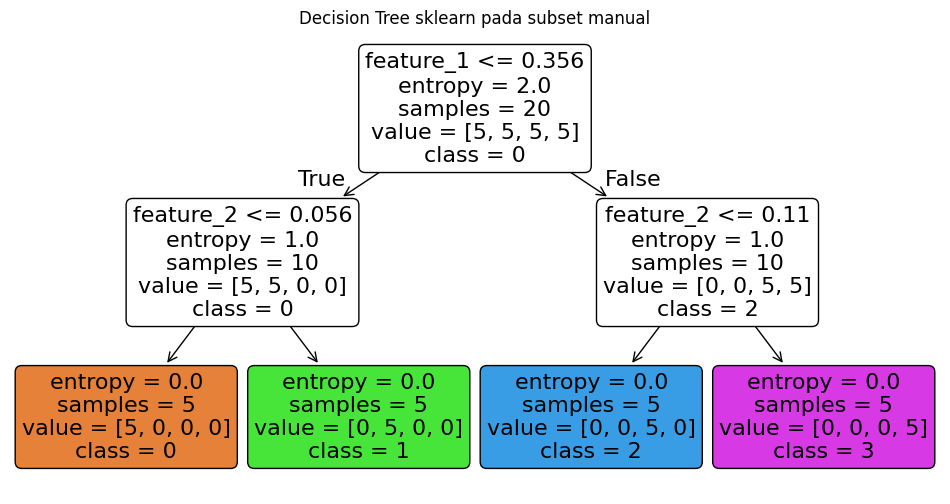

|--- feature_1 <= 0.36
|   |--- feature_2 <= 0.06
|   |   |--- class: 0
|   |--- feature_2 >  0.06
|   |   |--- class: 1
|--- feature_1 >  0.36
|   |--- feature_2 <= 0.11
|   |   |--- class: 2
|   |--- feature_2 >  0.11
|   |   |--- class: 3



In [30]:
X_manual = df_sample_manual[["feature_1", "feature_2"]]
y_manual = df_sample_manual["target"]

dt_manual_compare = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    random_state=RANDOM_STATE
)
dt_manual_compare.fit(X_manual, y_manual)

plt.figure(figsize=(12, 6))
plot_tree(
    dt_manual_compare,
    feature_names=["feature_1", "feature_2"],
    class_names=[str(c) for c in sorted(y_manual.unique())],
    filled=True,
    rounded=True
)
plt.title("Decision Tree sklearn pada subset manual")
plt.show()

print(export_text(dt_manual_compare, feature_names=["feature_1", "feature_2"].copy()))

### Jawaban Manual 4: Perbandingan Manual vs scikit-learn

Jawab secara kritis:
1. Apakah root node manual sama dengan root node scikit-learn?
2. Jika berbeda, jelaskan kemungkinan penyebabnya.
3. Mengapa threshold scikit-learn dapat berbeda dari median?
4. Apa kelebihan dan keterbatasan perhitungan manual?

**Jawaban:**  
Berdasarkan hasil dari decision tree scikit learn diatas, jika dibandingkan dengan perhitungan manual adalah sebagai berikut : 
1. Pada perhitungan manual dipilih feature_1 sebagai root node dengan threshold 0.355504. Pada gambar visualisasi scikit-learn root node menggunakan feature_1 <= 0.356, yang mana dapat disimpulkan bahwa node yang dipilih sama untuk kedua cara, yaitu dimulai dengan cabang kiri terlebih dahulu baik dari perhitungan manual maupun scikit-learn.
2. Terdapat sedikit perbedaan dari threshold dimana pada perhitungan manual 0.355504 dan dengan scikit-learn adalah 0.356, hal ini kemungkinan disebabkan oleh pembulatan pada visualisasi library scikit-learn (3 angka setelah koma), namun untuk export text melakukan pembulatan sebanyak lebih besar (2 angka setelah koma). Namun, secara keseluruhan nilai threshold ini adalah sama. 
3. Algoritma DT pada scikit-learn tidak membagi data berdasarkan nilai median fitur secara keseluruhan, namun dengan cara mengurutkan semua nilai unik dari sebuah fitur, selanjutnya mencari titik tengah diantara dua nilai data yang berurutan, selanjutnya menghitung information gain untuk setiap titik tengah tersebut, dan yang terakhir adalah memilih threshold yang memberikan pemisahan yang paling murno / information gain yang paling tinggi. Sehingga sangat jarang nilai threshold ini sama dengan nilai median distribusi fitur tersebut.
4. Kelebihan dari perhitungan manual adalah memberikan dasar pengetahuan mengenai algoritma DT sebelum menggunakan library scikit-learn agar mengerti pemahaman konsep Entropy dan Information Gain. Selanjutnya, jika kita telah mengetahui tentang bagaimana algoritma ini bekerja, maka kita bisa memastikan bahwa library scikit-learn menghasilkan hasil yang benar. Namun, kekurangannya adalah akan menghabiskan banyak sekali waktu apabila dataset berukuran besar, karena perhitungan manual akan menghitung entrophy dan titik tengah satu per satu, selanjutnya sangat memungkinkan terjadinya human error karena terdapat perhitungan manual yang sangat banyak. Serta kurang bisa dalam memvisualisasikan pruning dan hyperparameter. 

In [31]:
# Tandai bagian manual selesai setelah seluruh tabel utama dihasilkan
required_cols = {"feature", "threshold", "parent_entropy", "left_entropy", "right_entropy", "weighted_entropy", "information_gain"}
assert required_cols.issubset(set(ig_table.columns)), "Tabel Information Gain root belum lengkap."
assert len(ig_table) >= 2, "Minimal dua kandidat fitur harus dihitung."
assert root_node_selected is True, "Root node belum dipilih."
assert level2_simulation_done is True, "Simulasi level 2 belum dilakukan."

manual_calculation_done = True
print("Bagian Decision Tree manual telah selesai secara teknis.")

Bagian Decision Tree manual telah selesai secara teknis.


# 5. Split Data dan Preprocessing

Catatan penting:
- Decision Tree tidak wajib scaling karena berbasis split threshold.
- SVM sensitif terhadap skala fitur sehingga wajib menggunakan `StandardScaler`.


In [32]:
X_full = df.drop(columns=["target"])
y_full = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.25,
    stratify=y_full,
    random_state=RANDOM_STATE
)

print(X_train.shape, X_test.shape)

(450, 6) (150, 6)


# 6. Implementasi Decision Tree

Eksperimen minimal:
1. Decision Tree default/awal.
2. Decision Tree dengan pengendalian kompleksitas, misalnya `max_depth`, `min_samples_leaf`, atau `ccp_alpha`.


Accuracy Decision Tree awal: 0.9933333333333333
Accuracy Decision Tree terkendali: 0.9933333333333333


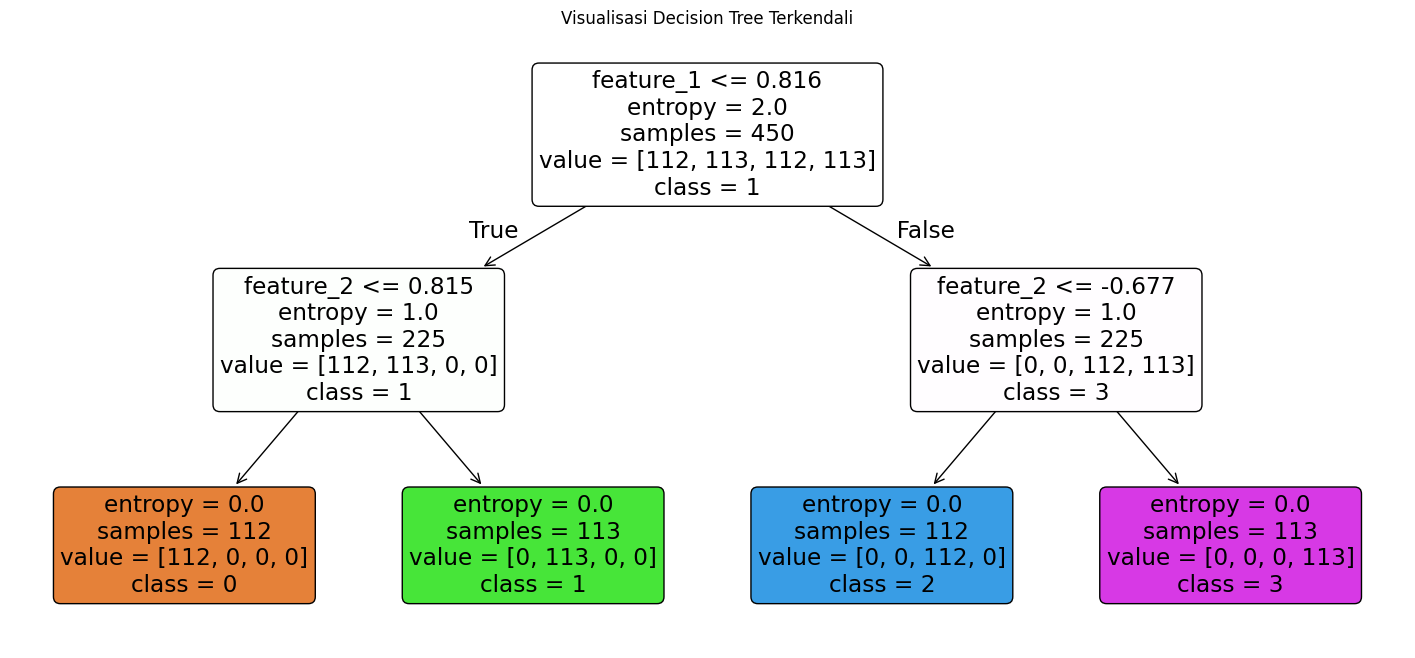

,feature,importance
0,feature_1,0.500004
1,feature_2,0.499996
2,feature_3,0.000000
3,feature_4,0.000000
4,feature_5,0.000000
5,feature_6,0.000000


In [33]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=None,
    random_state=RANDOM_STATE
)
dt_model.fit(X_train, y_train)

dt_pruned = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_leaf=8,
    random_state=RANDOM_STATE
)
dt_pruned.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_pruned_pred = dt_pruned.predict(X_test)

print("Accuracy Decision Tree awal:", accuracy_score(y_test, dt_pred))
print("Accuracy Decision Tree terkendali:", accuracy_score(y_test, dt_pruned_pred))

plt.figure(figsize=(18, 8))
plot_tree(
    dt_pruned,
    feature_names=X_full.columns,
    class_names=[str(c) for c in sorted(y_full.unique())],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Visualisasi Decision Tree Terkendali")
plt.show()

feature_importance = pd.DataFrame({
    "feature": X_full.columns,
    "importance": dt_pruned.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance)

### Jawaban Analisis Decision Tree

Tuliskan:
1. Apakah Decision Tree awal menunjukkan indikasi overfitting?
2. Bagaimana pengaruh `max_depth` dan `min_samples_leaf`?
3. Fitur apa yang paling penting menurut model?
4. Hubungkan hasil ini dengan konsep Information Gain.

**Jawaban:**  
Berdasarkan hasil visualisasi dan akurasi DT awal dan terkendali:
1. Berdasarkan nilai akurasi Decision Tree awal dan terkendali yang menghasilkan nilai sama persis yaitu 0.9933, yang artinya algoritma Decision Tree awal tidak mengalami overfitting yang merusak kinerjanya pada data uji. Karena klaster data pada fitur utama sudah terpisah dengan sangat jelas, maka dapat menemukan batas dengan sangat jelas. 
2. Pada code, max_depth dibatasi pada level 4, namun terlihat bahwa pada data uji yang digunakan tree sudah berhenti pada level 2, karena kelas sudah berhasil dipisahkan dengan sempurna. Namun, max_depth disini akan berfungsi mencegah algoritma untuk terlalu spesifik pada data latih. Selanjutnya dalam min_samples_leaf untuk membuat keputusan akhir harus memiliki 8 sample data, dimana aturan ini mencegah pohon membuat cabang baru hanya untuk memisahkan 1 atau 2 titik data outlier. Baik max_depth maupun min_samples_leaf mengurangi varians model, membuatnya lebih sederhana, lebih mudah diinterpretasikan oleh manusia, dan lebih robust data baru. 
3. Berdasarkan tabel Feature Importance, feature_1 (skor 0.500004) dan feature_2 (skor 0.499996) adalah dua fitur yang paling penting
Sedangkan, fitur lainnya (feature_3 hingga feature_6) memiliki skor 0.000000, dimana dianggap ini tidak berpengaruh pada pengambilan keputusan. Hal ini sangat selaras dengan gambar visualisasi tree, di mana model hanya menggunakan feature_1 untuk pemisahan pertama (root node), dan feature_2 untuk pemisahan kedua, mengabaikan fitur-fitur lainnya.
4. Feature importance pada Decision Tree scikit-learn dihitung berdasarkan seberapa besar sebuah fitur berhasil mengurangi ketidakmurnian seperti Entropy di seluruh cabang pohon. Penurunan ini dikenal sebagai Information Gain. Karena model memprioritaskan fitur yang memiliki information gain tertinggi dimana feature_1 memberikan Information Gain terbesar dengan menurunkan Entropy secara drastis dari 2.0 menjadi 1.0. Selanjutnya pada langkah kedua, feature_2 berhasil memberikan sisa Information Gain yang dibutuhkan untuk menurunkan Entropy dari 1.0 menjadi 0.0, yang berarti telah murni sempurna. Jika model menggunakan feature_3 hingga feature_6 yang memiliki feature importance 0.00, maka information gain yang diberikan nantinya akan lebih kecil, karena penggunaan fitur yang noisy tidak akan memberikan informasi tambahan yang berharga.

# 7. Implementasi SVM — Eksperimen Kernel Linear vs RBF

Bagian ini diperbarui agar perbedaan kernel **linear** dan **RBF** tampak jelas secara visual dan empiris.

Anda harus mengerjakan dua jalur eksperimen:

1. **Dataset utama multi-class**: digunakan untuk evaluasi akhir bersama Decision Tree.
2. **Dataset demonstrasi non-linear multi-class 2D**: digunakan khusus untuk membuktikan kapan kernel RBF lebih unggul daripada kernel linear.

Fokus analisis:
- Mengapa kernel linear gagal pada pola non-linear?
- Bagaimana RBF membentuk decision boundary yang melengkung?
- Bagaimana pengaruh `gamma` terhadap underfitting dan overfitting?
- Apakah RBF selalu lebih baik daripada linear?


In [34]:
# ===== 7.1 SVM pada dataset utama =====
svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1, random_state=RANDOM_STATE))
])

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma="scale", random_state=RANDOM_STATE))
])

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

svm_linear_pred = svm_linear.predict(X_test)
svm_rbf_pred = svm_rbf.predict(X_test)

print("Accuracy SVM Linear pada dataset utama:", accuracy_score(y_test, svm_linear_pred))
print("Accuracy SVM RBF pada dataset utama:", accuracy_score(y_test, svm_rbf_pred))

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.1, 1, 10]
}

svm_grid = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=RANDOM_STATE))
    ]),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy"
)
svm_grid.fit(X_train, y_train)

print("Best params SVM RBF:", svm_grid.best_params_)
print("Best CV score SVM RBF:", svm_grid.best_score_)
svm_best_pred = svm_grid.predict(X_test)
print("Accuracy SVM RBF tuned:", accuracy_score(y_test, svm_best_pred))


Accuracy SVM Linear pada dataset utama: 1.0
Accuracy SVM RBF pada dataset utama: 1.0
Best params SVM RBF: {'model__C': 10, 'model__gamma': 'scale'}
Best CV score SVM RBF: 1.0
Accuracy SVM RBF tuned: 0.9933333333333333


## 7.2 Dataset Demonstrasi Non-linear Multi-Class

Dataset berikut dibuat khusus agar mahasiswa dapat melihat perbedaan kernel secara jelas. Bentuk kelas berupa **cincin konsentris** sehingga pemisahan linear sulit dilakukan, sedangkan RBF mampu membuat boundary melengkung.

Dataset ini bukan pengganti dataset utama, melainkan **alat pembuktian visual** untuk memahami perilaku kernel.


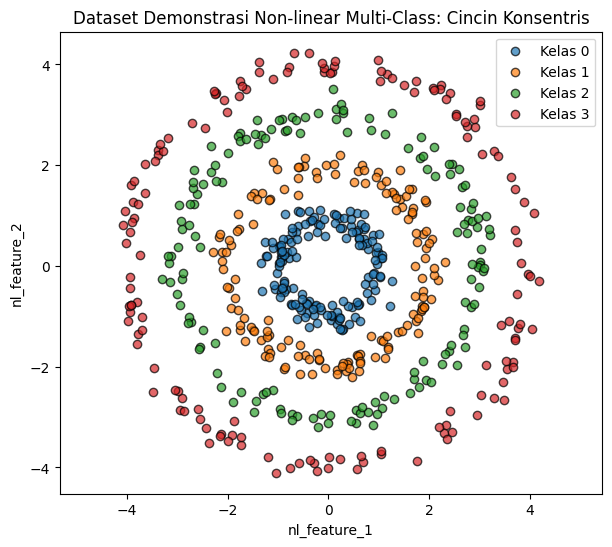

Jumlah kelas: 4
Distribusi kelas:


target
0    150
1    150
2    150
3    150
Name: count, dtype: int64

In [35]:
# ===== 7.2 Generate dataset non-linear multi-class 2D =====
rng = np.random.default_rng(RANDOM_STATE)
n_per_class = 150
radii = [1.0, 2.0, 3.0, 4.0]

X_nl_parts = []
y_nl_parts = []

for class_id, r_center in enumerate(radii):
    theta = rng.uniform(0, 2*np.pi, n_per_class)
    r = rng.normal(loc=r_center, scale=0.16, size=n_per_class)
    x1 = r * np.cos(theta)
    x2 = r * np.sin(theta)
    X_nl_parts.append(np.column_stack([x1, x2]))
    y_nl_parts.append(np.full(n_per_class, class_id))

X_nl = np.vstack(X_nl_parts)
y_nl = np.concatenate(y_nl_parts)

# Acak urutan data
perm = rng.permutation(len(y_nl))
X_nl = X_nl[perm]
y_nl = y_nl[perm]

X_nl_df = pd.DataFrame(X_nl, columns=["nl_feature_1", "nl_feature_2"])
y_nl_series = pd.Series(y_nl, name="target")

plt.figure(figsize=(7, 6))
for cls in sorted(np.unique(y_nl)):
    subset = X_nl_df[y_nl_series == cls]
    plt.scatter(subset["nl_feature_1"], subset["nl_feature_2"], label=f"Kelas {cls}", alpha=0.7, edgecolor="k")
plt.title("Dataset Demonstrasi Non-linear Multi-Class: Cincin Konsentris")
plt.xlabel("nl_feature_1")
plt.ylabel("nl_feature_2")
plt.legend()
plt.axis("equal")
plt.show()

print("Jumlah kelas:", len(np.unique(y_nl)))
print("Distribusi kelas:")
display(y_nl_series.value_counts().sort_index())


## 7.3 Fungsi Visualisasi Decision Boundary 2D

Fungsi berikut wajib digunakan untuk membandingkan kernel linear dan RBF secara berdampingan.


In [36]:
def plot_decision_boundary_2d(model, X, y, title):
    """Plot decision boundary untuk data 2D berbentuk DataFrame atau array."""
    if isinstance(X, pd.DataFrame):
        X_values = X.values
        col_names = list(X.columns)
        grid_to_model = "dataframe"
    else:
        X_values = np.asarray(X)
        col_names = ["feature_1", "feature_2"]
        grid_to_model = "array"

    x_min, x_max = X_values[:, 0].min() - 0.8, X_values[:, 0].max() + 0.8
    y_min, y_max = X_values[:, 1].min() - 0.8, X_values[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350)
    )

    grid_array = np.c_[xx.ravel(), yy.ravel()]
    if grid_to_model == "dataframe":
        grid = pd.DataFrame(grid_array, columns=col_names)
    else:
        grid = grid_array

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.25)
    for cls in sorted(np.unique(y)):
        subset = X_values[np.asarray(y) == cls]
        plt.scatter(subset[:, 0], subset[:, 1], label=f"Kelas {cls}", alpha=0.78, edgecolor="k")
    plt.title(title)
    plt.xlabel(col_names[0])
    plt.ylabel(col_names[1])
    plt.legend()
    plt.axis("equal")
    plt.show()


## 7.4 Perbandingan Linear vs RBF pada Dataset Non-linear

Eksperimen ini wajib memperlihatkan bahwa:
- SVM Linear membentuk batas keputusan relatif lurus sehingga sulit memisahkan kelas berbentuk cincin.
- SVM RBF mampu membentuk batas keputusan non-linear yang mengikuti struktur data.


Accuracy SVM Linear pada dataset non-linear: 0.32
Accuracy SVM RBF pada dataset non-linear: 0.9933333333333333


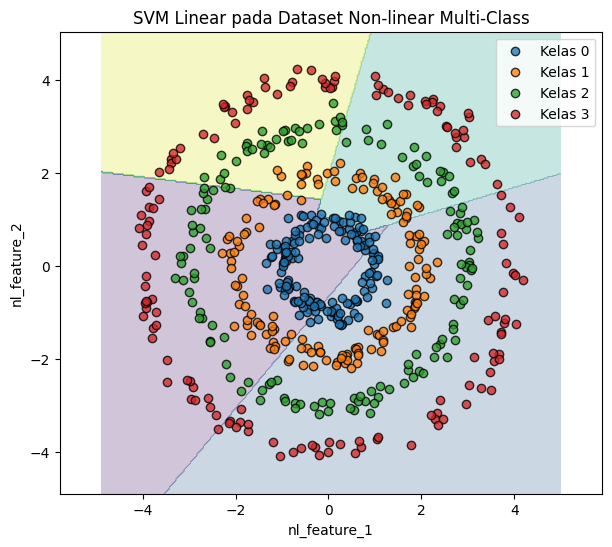

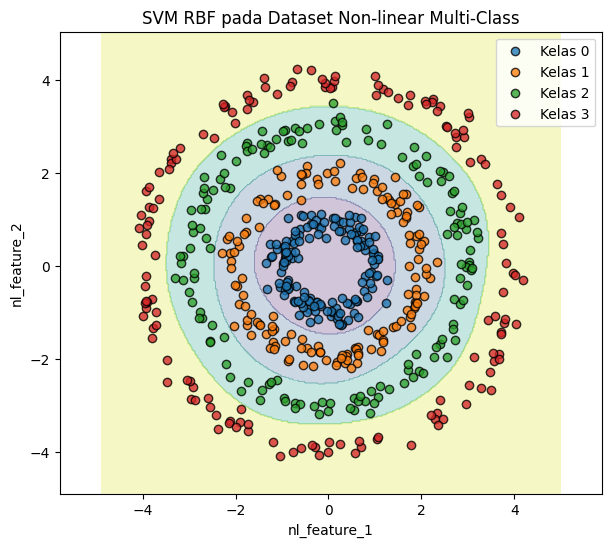

In [37]:
# ===== 7.4 Train/test split untuk dataset non-linear =====
X_nl_train, X_nl_test, y_nl_train, y_nl_test = train_test_split(
    X_nl_df,
    y_nl_series,
    test_size=0.25,
    stratify=y_nl_series,
    random_state=RANDOM_STATE
)

svm_linear_nl = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1, random_state=RANDOM_STATE))
])

svm_rbf_nl = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma=1, random_state=RANDOM_STATE))
])

svm_linear_nl.fit(X_nl_train, y_nl_train)
svm_rbf_nl.fit(X_nl_train, y_nl_train)

svm_linear_nl_pred = svm_linear_nl.predict(X_nl_test)
svm_rbf_nl_pred = svm_rbf_nl.predict(X_nl_test)

print("Accuracy SVM Linear pada dataset non-linear:", accuracy_score(y_nl_test, svm_linear_nl_pred))
print("Accuracy SVM RBF pada dataset non-linear:", accuracy_score(y_nl_test, svm_rbf_nl_pred))

plot_decision_boundary_2d(svm_linear_nl, X_nl_df, y_nl_series, "SVM Linear pada Dataset Non-linear Multi-Class")
plot_decision_boundary_2d(svm_rbf_nl, X_nl_df, y_nl_series, "SVM RBF pada Dataset Non-linear Multi-Class")


## 7.5 Eksperimen Gamma pada Kernel RBF

Jalankan seluruh nilai `gamma` berikut. Amati perubahan boundary:
- `gamma` sangat kecil → boundary terlalu halus, cenderung underfitting, kadang terlihat mirip linear.
- `gamma` sedang → boundary mengikuti struktur non-linear secara wajar.
- `gamma` terlalu besar → boundary sangat lokal dan berisiko overfitting.


Gamma = 0.01 | Accuracy = 0.2600


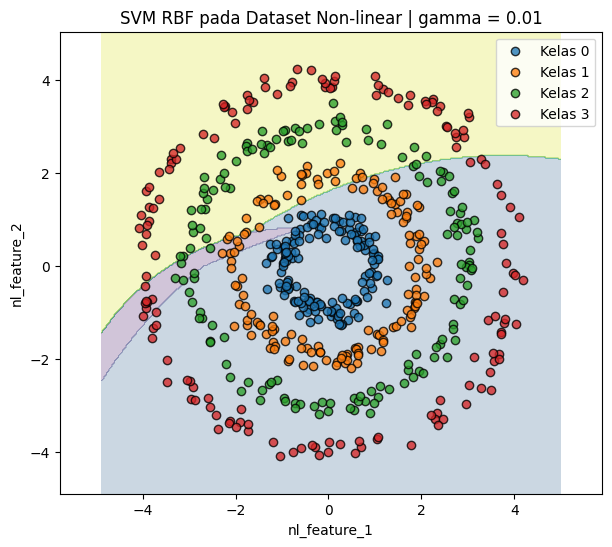

Gamma = 0.1 | Accuracy = 0.9133


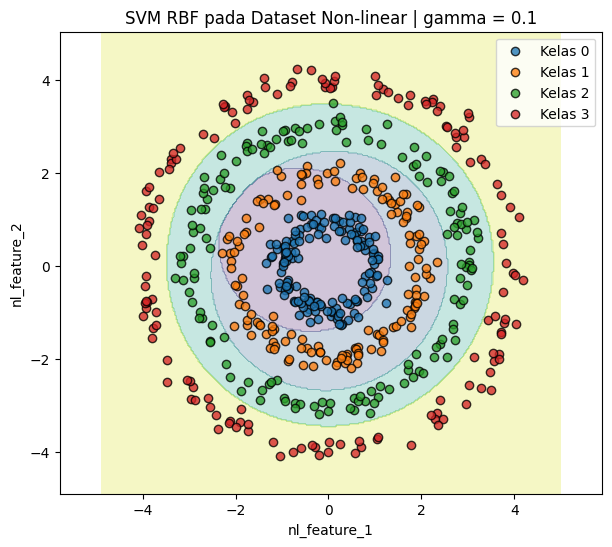

Gamma = 1 | Accuracy = 0.9933


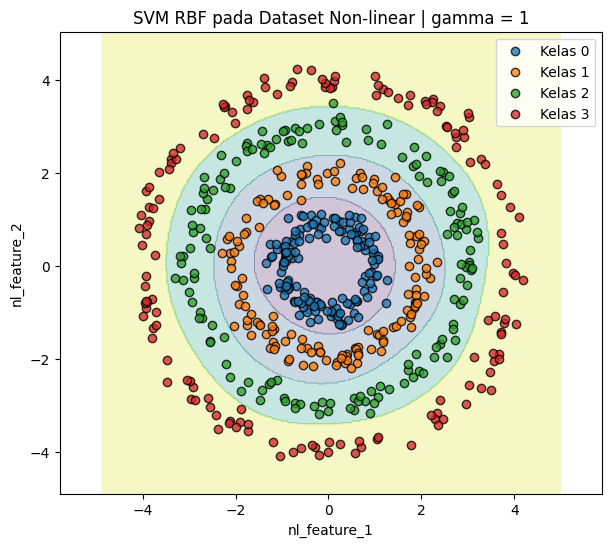

Gamma = 10 | Accuracy = 0.9933


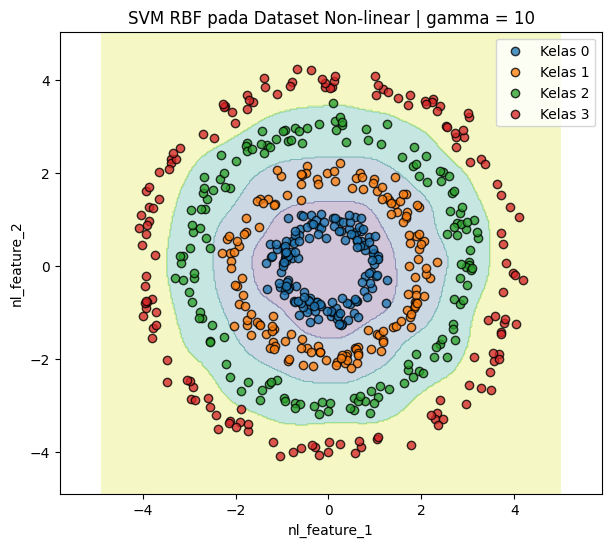

Gamma = 50 | Accuracy = 0.9933


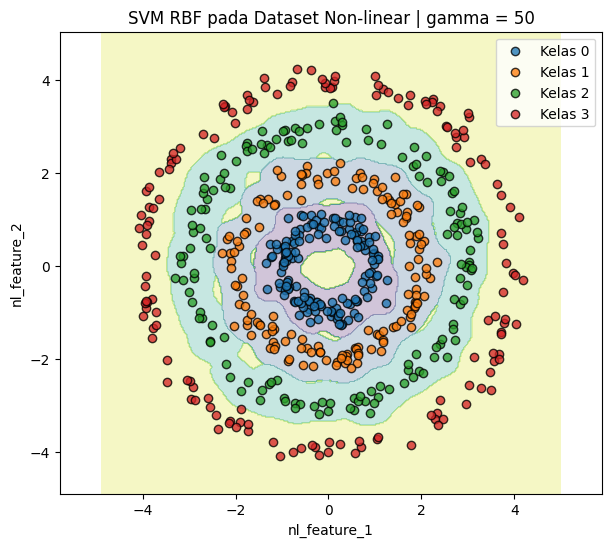

,gamma,accuracy
0,0.01,0.260000
1,0.10,0.913333
2,1.00,0.993333
3,10.00,0.993333
4,50.00,0.993333


In [38]:
# ===== 7.5 Eksperimen gamma wajib =====
gamma_values = [0.01, 0.1, 1, 10, 50]
gamma_experiment_results = []

for gamma_value in gamma_values:
    model_gamma = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1, gamma=gamma_value, random_state=RANDOM_STATE))
    ])
    model_gamma.fit(X_nl_train, y_nl_train)
    pred_gamma = model_gamma.predict(X_nl_test)
    acc_gamma = accuracy_score(y_nl_test, pred_gamma)
    gamma_experiment_results.append({
        "gamma": gamma_value,
        "accuracy": acc_gamma
    })

    print(f"Gamma = {gamma_value} | Accuracy = {acc_gamma:.4f}")
    plot_decision_boundary_2d(
        model_gamma,
        X_nl_df,
        y_nl_series,
        f"SVM RBF pada Dataset Non-linear | gamma = {gamma_value}"
    )

gamma_results_df = pd.DataFrame(gamma_experiment_results)
display(gamma_results_df)


### Jawaban Analisis SVM — Wajib Diisi

Jawab berdasarkan **hasil plot dan metrik**, bukan hanya teori umum.

1. Pada dataset non-linear multi-class, mengapa SVM Linear sulit memisahkan kelas?
2. Bagaimana bentuk decision boundary SVM RBF dibandingkan SVM Linear?
3. Pada nilai `gamma` berapa model tampak underfitting? Jelaskan berdasarkan plot.
4. Pada nilai `gamma` berapa model berisiko overfitting? Jelaskan berdasarkan plot.
5. Tunjukkan kondisi ketika RBF tampak mirip linear. Apa penyebabnya?
6. Apakah RBF selalu lebih baik daripada linear? Jelaskan dengan mengacu pada dataset utama dan dataset non-linear.

**Jawaban:**  
Berdasarkan hasil plot dan metrik yang dilakukan pada tahap SVM sebelumnya, didapatkan hasil :
1. Pada visualisasi SVM Linear pada Non-linear dataset diatas, terlihat bahwa SVM Linear hanya mampu menggambar batas keputusan berupa garis lurus / hyperplane datar karena SVM Linear diprogram untuk mencari garis lurus yang memaksimalkan jarak antar kelas. Jika dilihat pada dataset memiliki pola melingkar di mana kelas-kelas mengelilingi satu sama lain seperti cincin. Dimana kelas 0 berada di tengah, dikelilingi kelas 1, lalu kelas 2, dan paling luar kelas 3. Karena SVM Linear hanya mampu memberikan garis lurus maka ia tidak akan pernah bisa mengelompokkan dalam bentuk lingkaran, akibatnya klasifikasi menjadi tidak tepat. Sehingga, contoh klasifikasi dengan SVM Linear ini adalah contoh gagal dalam klasifikasi kelas di seluruh kelas. 
2. Jika dilihat pada visualisais SVM Linear pada Non-linear dataset serta SVM RBF pada Non-linear dataset, bentuk decision boundary SVM Linear yaitu membuat batas keputusan berupa garis lurus / hyperplane yang sangat kaku, sedangkan SVM dengan Radial Basis Function (RBF) membuat batas keputusan berupa kurva tertutup yang fleksibel dan dapat melingkari kelompok data secara spesifik. 
3. Jika dilihat pada visualisasi SVM RBF pada Dataset Linear dengan variasi beberapa gamma diatas, terlihat bahwa terdapat beberapa variasi dengan berbagai hasil yang diberikan, terlihat terdapat model yang underfitting, dimana model tidak bisa menangkap pola lingkaran dari data batas yang terbentuk hanya berupa kurva landai yang membelah data secara kasar, sehingga banyak kelas yang salah diklasifikasikan yaitu pada variasi gamma 0.01. Selain itu, berdasarkan metriks akurasi terlihat bahwa akurasi gamma = 0.01 hanya mencapai 0.2600. 
4. Jika dilihat pada visualisasi SVM RBF pada Dataset Linear dengan variasi beberapa gamma diatas, terlihat bahwa terdapat beberapa variasi dengan berbagai hasil yang diberikan, terlihat terdapat model yang berpotensi overfitting, yaitu pada gamma = 50. Dimana terlihat bahwa decision boundary sudah sangat spesifik dengan bentuk bergerigi yang secara ketat melingkari satu atau dua titik data. Meskipun pada metriks akurasi tercatat bahwa akurasi 0.9933, bentuk ini mempelajari noise yang dimana hasil akan memberikan pola yang sangat spesifik, sehingga ketika diberikan data baru akan menyebabkan kesalahan prediksi.
5. Terlihat pada gamma = 0.01, garis yang terbentuk pada decision boundary terlihat sangat landai, hampir menyerupai garis lurus yang dihasilkan oleh SVM Linear. Penyebabnya karena parameter gamma menentukan radius pengaruh dari setiap titik data latih. Semakin kecil nilai gamma, maka semakin jauh radius pengaruh titik tersebut. Ketika gamma mendekati nol/sangat kecil, fungsi eksponensial pada RBF menjadi sangat datar. Akibatnya, model menganggap semua titik data memiliki kemiripan yang luas secara spasial, sehingga decision boundary yang terbentuk kehilangan fleksibilitasnya untuk melengkung tajam dan berakhir dengan bentuk yang kaku, menyerupai hyperplane linear.
6. Pada dataset utama dengan feature_1 & feature_2 yang telah terpisah secara sempurna dalam bentuk 4 klaster di kuadran berbeda yang linearly separable, SVM Linear menjadi pilihan yang tepat, model linear lebih sederhana, komputasinya lebih ringan, dan sangat tahan terhadap overfitting. Menggunakan RBF di sana berisiko menambah kompleksitas yang tidak perlu. Namun, pada dataset non-linear karena datanya berbentuk lingkaran, pilihan yang tepat menggunakan RBF, karena dapat menarik decision boundary kurva tertutup / lingkaran yang akan memisahkan data dengan berbentuk cincin. Hal tersebut tidak mungkin dilakukan oleh SVM Linear. Sehingga pemilihan Linear / RBF ditentukan oleh dataset yang dimiliki.

# 8. Evaluasi Model

,model,accuracy
2,SVM Linear,1.000000
3,SVM RBF,1.000000
0,Decision Tree Awal,0.993333
1,Decision Tree Terkendali,0.993333
4,SVM RBF Tuned,0.993333



Decision Tree Awal
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        38
           3       1.00      0.97      0.99        37

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



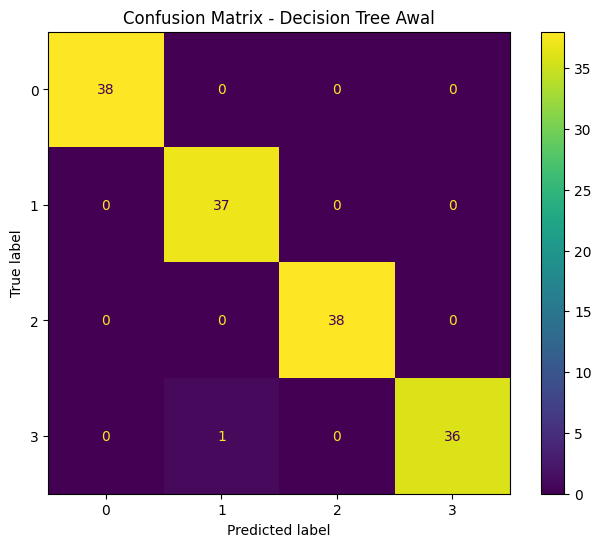


Decision Tree Terkendali
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        38
           3       1.00      0.97      0.99        37

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



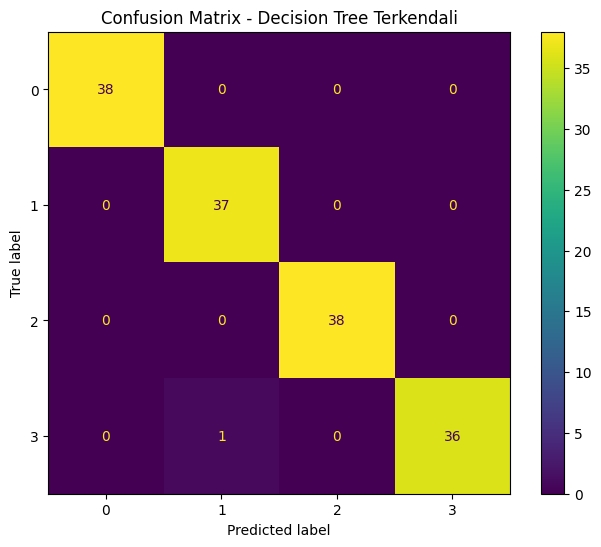


SVM Linear
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00        37

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



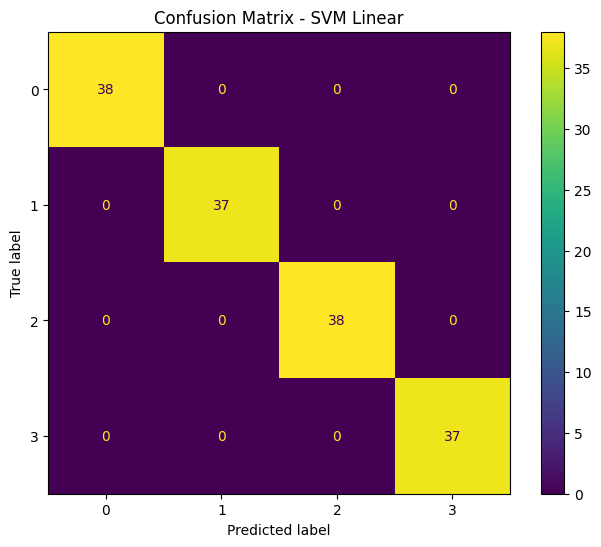


SVM RBF
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00        37

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



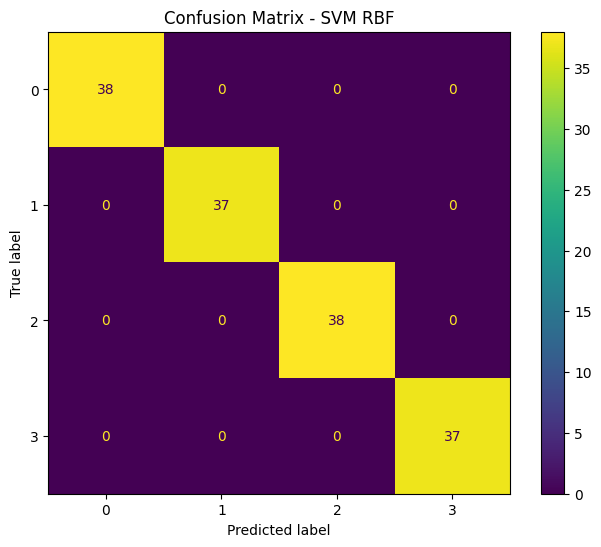


SVM RBF Tuned
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      0.97      0.99        38
           3       0.97      1.00      0.99        37

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



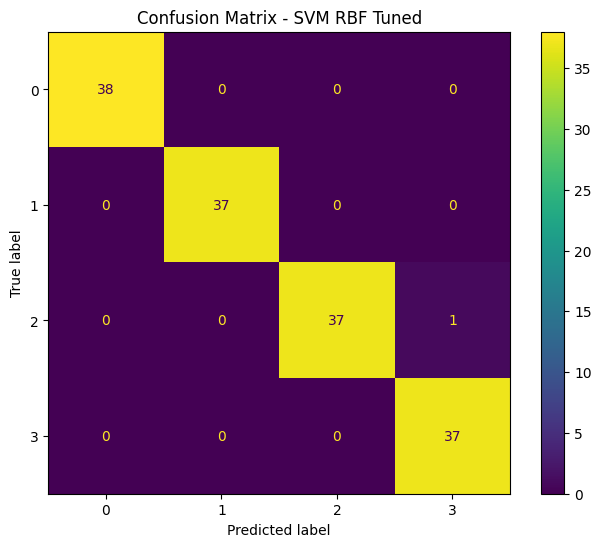

In [39]:
models = {
    "Decision Tree Awal": (dt_model, dt_pred),
    "Decision Tree Terkendali": (dt_pruned, dt_pruned_pred),
    "SVM Linear": (svm_linear, svm_linear_pred),
    "SVM RBF": (svm_rbf, svm_rbf_pred),
    "SVM RBF Tuned": (svm_grid, svm_best_pred),
}

summary = []
for name, (model, pred) in models.items():
    summary.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred)
    })

summary_df = pd.DataFrame(summary).sort_values("accuracy", ascending=False)
display(summary_df)

for name, (model, pred) in models.items():
    print("\n", "="*70)
    print(name)
    print(classification_report(y_test, pred))
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

### Jawaban Analisis Evaluasi

Tuliskan:
1. Model mana yang paling baik berdasarkan accuracy dan classification report?
2. Kelas mana yang paling sering keliru diklasifikasikan?
3. Apakah accuracy saja cukup? Jelaskan.
4. Apakah model terbaik juga paling mudah dijelaskan?

**Jawaban:**  
Berdasarkan hasil evaluasi model diatas, disimpulkan bahwa : 
1. Berdasarkan tabel akurasi dan visualisasi per model didapatkan bahwa SVM Linear dan SVM RBF (awal) adalah model yang paling baik. Keduanya mencapai akurasi sempurna, yaitu 1.000000 (100%). Hal ini juga didukung oleh confusion matrix mereka, di mana semua tebakan berada di garis diagonal utama (38, 37, 38, 37), yang berarti tidak ada satu pun data uji yang salah diklasifikasikan. 
2. Pada Decision Tree (Awal & Terkendali) terdapat 1 sampel dari Kelas 3 yang keliru diprediksi sebagai Kelas 1. Selanjutnya pada SVM RBF Tuned terdapat 1 sampel dari Kelas 2 yang keliru diprediksi sebagai Kelas 3. Sehingga dapat disimpulkan bahwa, Kelas 3 sedikit lebih rentan mengalami kesalahan. 
3. Untuk best practice diperlukan juga confusion matriks, F1, Recall, dan Precision juga, karena jika menggunakan akurasi saja hal tersebut dapat berakibat bias, karena misal jika suatu data berisi 90% kelas 0, dan model akan terus menerus kelas 0 maka akan mendapatkan akurasi 90%, padahal ia salah menebak kelas lainnya. Namun, jika dilihat pada data yang kita miliki sekarang, karena distribusi kelasnya balanced, sehingga akurasi saja cukup untuk menyimpulkan kinerja model.
4. Model terbaik yang kita dapatkan dari analisis diatas adalah SVM, namun, SVM sangat susah dijelaskan secara matematis, seperti RBF memproyeksikan data ke dimensi tinggi dan bagaimana batas keputusannya melengkung di ruang hiper tersebut. Namun, sebaliknya DT walaupun memiliki akurasi lebih rendah daripada SVM, ia lebih mudah dijelaskan secara matematis. 

# 9. Visualisasi Decision Boundary Terpadu

Bagian ini merangkum visualisasi boundary pada dua konteks:

1. **Dataset utama dengan `feature_1` dan `feature_2`** untuk membandingkan Decision Tree, SVM Linear, dan SVM RBF pada data multi-class utama.
2. **Dataset non-linear multi-class** yang sudah divisualisasikan pada Bagian 7 untuk memperlihatkan perbedaan kernel linear dan RBF secara lebih tegas.

Catatan: visualisasi 2D hanya memakai dua fitur, sehingga tidak selalu merepresentasikan keseluruhan performa model pada semua fitur.


Dataset utama 2D:
Accuracy DT 2D: 0.9933333333333333
Accuracy SVM Linear 2D: 0.9933333333333333
Accuracy SVM RBF 2D: 1.0


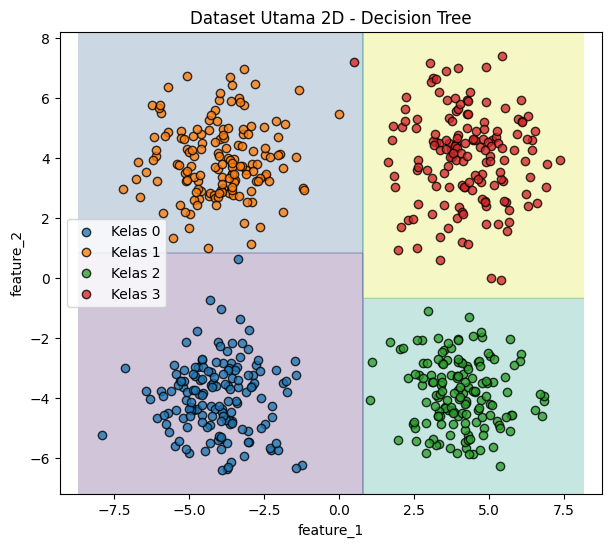

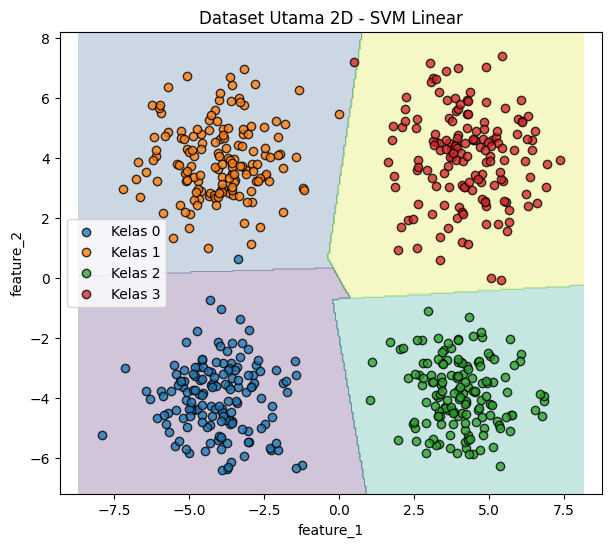

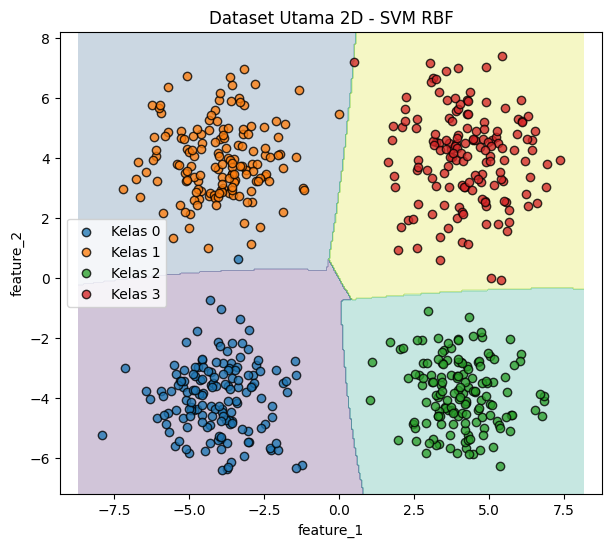

In [40]:
# ===== 9.1 Decision boundary pada dataset utama menggunakan feature_1 dan feature_2 =====
X2 = df[["feature_1", "feature_2"]]
y2 = df["target"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.25,
    stratify=y2,
    random_state=RANDOM_STATE
)

dt_2d = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=RANDOM_STATE
)
dt_2d.fit(X2_train, y2_train)

svm_linear_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1, random_state=RANDOM_STATE))
])
svm_linear_2d.fit(X2_train, y2_train)

svm_rbf_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma="scale", random_state=RANDOM_STATE))
])
svm_rbf_2d.fit(X2_train, y2_train)

print("Dataset utama 2D:")
print("Accuracy DT 2D:", accuracy_score(y2_test, dt_2d.predict(X2_test)))
print("Accuracy SVM Linear 2D:", accuracy_score(y2_test, svm_linear_2d.predict(X2_test)))
print("Accuracy SVM RBF 2D:", accuracy_score(y2_test, svm_rbf_2d.predict(X2_test)))

plot_decision_boundary_2d(dt_2d, X2, y2, "Dataset Utama 2D - Decision Tree")
plot_decision_boundary_2d(svm_linear_2d, X2, y2, "Dataset Utama 2D - SVM Linear")
plot_decision_boundary_2d(svm_rbf_2d, X2, y2, "Dataset Utama 2D - SVM RBF")

# Variabel penanda untuk validasi otomatis
boundary_visualization_done = True
svm_kernel_comparison_done = True


### Jawaban Analisis Decision Boundary

Tuliskan analisis berbasis plot:

1. Pada dataset utama 2D, apakah boundary SVM RBF berbeda jauh dari SVM Linear? Mengapa?
2. Pada dataset non-linear multi-class, mengapa perbedaan Linear dan RBF tampak lebih jelas?
3. Bagaimana bentuk decision boundary Decision Tree dibandingkan SVM?
4. Jelaskan hubungan antara bentuk boundary, karakteristik data, dan risiko overfitting.

**Jawaban:**  
Berdasarkan hasil visualisasi diatas, dapat disimpulkan bahwa:
1. Boundary decision pada SVM RBF dan SVM Linear pada 2D tidak terlihat jauh berbeda. Keduanya membagi ruang menjadi empat area yang terpusat di tengah. Perbedaan utamanya hanyalah SVM Linear menggunakan garis lurus yang kaku, sedangkan SVM RBF menggunakan kurva yang sedikit melengkung dan lebih halus. Karena dataset utama ini pada dasarnya memiliki distribusi yang linearly separable, sehingga algoritma RBF tidak perlu melengkungkan ruang secara ekstrem. Lengkungan kecil inilah yang membuat SVM RBF berhasil mencapai akurasi 1.0, menangkap satu atau dua titik di perbatasan yang gagal ditangkap oleh garis kaku SVM Linear.
2. Pada dataset non-linear, seperti berbentuk pola lingkaran pada dataset yang kita miliki, SVM Linear hanya bisa membuat garis lurus dan tidak bisa mengurung lingkaran dengan satu garis lurus, sehingga menyebabkan underfitting pada data. Sebaliknya, kernel RBF memproyeksikan data ke dimensi yang lebih tinggi, yang memungkinkan batas keputusannya kembali ke wujud 2D sebagai kurva tertutup yang dengan indah melingkari setiap cincin kelas.
3. Pada Decision Tree batas keputusannya selalu tegak lurus terhadap sumbu fitur/axis, membentuk garis horizontal & vertikal. Hal ini terjadi karena Decision Tree mengevaluasi fitur satu per satu secara berurutan. Sedangkan pada SVM baik linear & RBF batas keputusannya bisa miring atau melengkung bebas. Algoritma SVM mengevaluasi kombinasi dari semua fitur secara bersamaan untuk menarik garis atau kurva pemisah yang paling optimal. 
4. Untuk beberapa bentuk boundary :
- Boundary Linear : Boundary ini sangat baik dan minim risiko overfitting pada data dengan karakteristik yang sederhana dan terpisah jelas. Namun, jika dipaksakan pada data dengan pola melengkung/kompleks, model akan underfitting.
- Boundary Decision Tree / Tegak Lurus : Sangat rentan mengalami overfitting jika data sebenarnya memiliki batas pemisah berbentuk diagonal. Untuk membuat garis miring, Decision Tree terpaksa harus membuat banyak sekali potongan vertikal/horizontal kecil. Semakin banyak potongan tersebut, semakin model menghafal noise data.
- Boundary yang Fleksible : Boundary ini memiliki kemampuan tertinggi dalam menyesuaikan diri dengan karakteristik data serumit apa pun. Namun, hal ini juga membawa risiko overfitting tertinggi. Jika parameternya tidak dikendalikan, maka bentuk boundary akan melekuk-lekuk untuk mengurung outlier yang berakibat fatal saat model diuji dengan data baru.


# 10. Pertanyaan Konseptual Wajib

Jawab pertanyaan berikut secara ringkas tetapi argumentatif.

1. Apakah entropy selalu lebih baik daripada gini impurity?
2. Jika seluruh fitur memiliki Information Gain = 0, apa artinya?
3. Mengapa threshold sangat memengaruhi struktur Decision Tree?
4. Apakah Decision Tree dapat menangani data non-linear tanpa transformasi fitur?
5. Mengapa SVM Linear dapat gagal pada data non-linear?
6. Apa konsekuensi jika nilai `C` terlalu besar pada SVM?
7. Mengapa interpretabilitas Decision Tree umumnya lebih tinggi daripada SVM RBF?

**Jawaban:**  
1. Tidak selalu lebih baik. Secara performa baik entrophy maupun gini impurity sama-sama menghasilkan tree yang identik, namun perbedaan yang terlihat itu pada beban komputasinya. Gini Impurity jauh lebih cepat dihitung karena hanya menggunakan probabilitas kuadrat, sedangkan Entropy menggunakan operasi logaritma yang memakan lebih banyak sumber daya komputasi. Entropy hanya dipilih jika kita membutuhkan penalti yang sedikit lebih merata dan halus terhadap kemurnian data.
2. Jika pemisahan menggunakan fitur apa pun tidak menghasilkan penurunan ketidakpastian, ini mengindikasikan bahwa fitur-fitur tersebut tidak memiliki korelasi sedikit pun dengan target kelas. Sehingga tidak ada fitur yang prediktif. Kemungkinan besar dataset tersebut berisi noise acak, atau memang dibutuhkan feature engineering lebih lanjut untuk memunculkan pola yang bersembunyi. 
3. Karena cascading effect dari algoritma greedy. Dimana threshold menentukan di mana titik potong data berada. Jika threshold di root node atau node atas sedikit bergeser, maka subset data yang jatuh ke cabang kiri dan kanan akan berubah total. Karena setiap cabang di bawahnya dibangun berdasarkan subset spesifik tersebut, satu pergeseran kecil di tingkat atas akan merombak seluruh struktur pohon hingga ke level daun.
4. Algoritma Decision Tree tidak berasumsi bahwa hubungan antar data bersifat linear. Model ini menangani data non-linear dengan cara memotong ruang fitur menjadi sub-ruang berbentuk kotak-kotak dan menyusunnya sehingga bisa mendekati pola non linear. 
5. Karena SVM Linear memiliki kinerja sebatas berupa garis lurus, sehingga jika distribusi data bersifat non linear seperti melingkar, menyilang, atau konsentris, tidak ada satu pun garis lurus yang bisa membelah ruang tersebut tanpa kesalahan fatal.
6. Parameter C mengatur penalti model terhadap kesalahan klasifikasi. Jika C sangat besar, SVM akan dipaksa menerapkan hard margin, dimana model akan memprioritaskan hafalan agar tidak ada satupun data latih yang salah diklasifikasikan, bahkan jika itu adalah data outlier. Konsekuensinya, margin menjadi sangat sempit, batas keputusannya menjadi kaku, dan performanya akan anjlok saat berhadapan dengan data uji yang baru. Sehingga model akan mengalami overfitting.
7. Keputusan Decision Tree berakar dari dimensi fitur yang asli dan dapat ditelusuri langsung layaknya diagram alir, sebaliknya, SVM RBF menggunakan matematika kompleks (Kernel Trick) untuk melipat dan memproyeksikan data ke dimensi abstrak tak terhingga untuk menemukan area pemisah, sangat kompleks untuk divisualisasikan dengan bahasa manusia. 

# 11. Validasi Otomatis Notebook

Jalankan sel ini sebelum mengumpulkan. Validasi ini tidak menggantikan penilaian dosen/asisten, tetapi membantu memastikan komponen teknis utama sudah dikerjakan.


In [41]:
# ===== Auto-check teknis =====
checks = {}

# Identitas
checks["identitas_terisi"] = all([
    isinstance(NAMA, str) and NAMA.strip() != "",
    isinstance(NIM, str) and NIM.strip() != "",
    isinstance(KELAS, str) and KELAS.strip() != "",
    isinstance(DEKLARASI_AI, str) and len(DEKLARASI_AI.strip()) >= 80
])

# Dataset utama
checks["dataset_utama_tersedia"] = isinstance(df, pd.DataFrame) and df.shape[0] >= 500 and "target" in df.columns
checks["dataset_utama_multiclass"] = df["target"].nunique() >= 3

# Manual Decision Tree
checks["fungsi_entropy_ada"] = callable(entropy)
checks["fungsi_ig_ada"] = callable(information_gain_for_threshold)
checks["ig_table_lengkap"] = "ig_table" in globals() and required_cols.issubset(set(ig_table.columns))
checks["manual_calculation_done"] = manual_calculation_done is True
checks["root_node_selected"] = root_node_selected is True
checks["level2_simulation_done"] = level2_simulation_done is True

# Model utama
checks["decision_tree_digunakan"] = isinstance(dt_model, DecisionTreeClassifier) and isinstance(dt_pruned, DecisionTreeClassifier)
checks["svm_utama_digunakan"] = all(name in globals() for name in ["svm_linear", "svm_rbf", "svm_grid"])
checks["evaluasi_utama_ada"] = "summary_df" in globals() and len(summary_df) >= 4

# Dataset non-linear khusus SVM
checks["dataset_nonlinear_svm_ada"] = all(name in globals() for name in ["X_nl_df", "y_nl_series"])
checks["dataset_nonlinear_multiclass"] = "y_nl_series" in globals() and y_nl_series.nunique() >= 3
checks["svm_linear_vs_rbf_nonlinear_ada"] = all(name in globals() for name in ["svm_linear_nl", "svm_rbf_nl"])
checks["gamma_experiment_done"] = (
    "gamma_values" in globals()
    and "gamma_results_df" in globals()
    and len(gamma_values) >= 5
    and set([0.01, 0.1, 1, 10]).issubset(set(gamma_values))
    and len(gamma_results_df) >= 5
)

# Validasi agar perbedaan linear vs RBF benar-benar dapat diamati pada dataset non-linear
if all(name in globals() for name in ["svm_linear_nl_pred", "svm_rbf_nl_pred", "y_nl_test"]):
    acc_linear_nl = accuracy_score(y_nl_test, svm_linear_nl_pred)
    acc_rbf_nl = accuracy_score(y_nl_test, svm_rbf_nl_pred)
    checks["rbf_lebih_baik_di_dataset_nonlinear"] = acc_rbf_nl > acc_linear_nl + 0.10
else:
    checks["rbf_lebih_baik_di_dataset_nonlinear"] = False

# Visualisasi boundary
checks["boundary_models_utama_2d"] = all(name in globals() for name in ["dt_2d", "svm_linear_2d", "svm_rbf_2d"])
checks["boundary_visualization_done"] = "boundary_visualization_done" in globals() and boundary_visualization_done is True
checks["svm_kernel_comparison_done"] = "svm_kernel_comparison_done" in globals() and svm_kernel_comparison_done is True

check_df = pd.DataFrame([{"komponen": k, "status": v} for k, v in checks.items()])
display(check_df)

failed = [k for k, v in checks.items() if not v]
if failed:
    raise AssertionError("Komponen berikut belum lengkap atau belum memenuhi syarat: " + ", ".join(failed))
else:
    print("SELURUH VALIDASI TEKNIS LULUS. Silakan periksa kembali jawaban analisis sebelum mengumpulkan.")


,komponen,status
0,identitas_terisi,True
1,dataset_utama_tersedia,True
2,dataset_utama_multiclass,True
3,fungsi_entropy_ada,True
4,fungsi_ig_ada,True
5,ig_table_lengkap,True
6,manual_calculation_done,True
7,root_node_selected,True
8,level2_simulation_done,True
9,decision_tree_digunakan,True


SELURUH VALIDASI TEKNIS LULUS. Silakan periksa kembali jawaban analisis sebelum mengumpulkan.


# 12. Ringkasan Kesimpulan Akhir

Tuliskan kesimpulan akhir dalam 2–3 paragraf:
- model terbaik berdasarkan hasil eksperimen,
- trade-off antara akurasi dan interpretabilitas,
- pelajaran utama dari pembentukan Decision Tree manual dengan Entropy dan Information Gain.

**Kesimpulan:**  
Berdasarkan eksperimen yang telah dilakukan sebelumnya, Support Vector Machine (SVM) dengan kernel RBF terbukti menjadi model yang paling unggul dan tangguh secara performa. Hal ini dibuktikan dengan model ini berhasil mencapai akurasi sempurna (100%) pada dataset utama, serta pada dataset multi-class dengan pola non-linear di mana ia mampu menggambar batas keputusan kurva yang sangat presisi. Sebagai perbandingan, SVM Linear mengalami underfitting pada data non-linear, sementara Decision Tree, meskipun memberikan akurasi kompetitif (99.3%), membentuk batas keputusan tegak lurus yang kaku dan lebih berisiko mengalami overfitting jika hiperparameternya tidak dikendalikan dengan pruning.  

Meskipun SVM RBF memiliki akurasi tertinggi, eksperimen ini juga menyoroti dengan jelas trade-off antara akurasi dan interpretabilitas. SVM RBF beroperasi dengan mentransmisikan data ke dimensi tinggi menggunakan Kernel Trick membuat proses pengambilan keputusannya sangat abstrak dan sulit dijelaskan secara matematis kepada manusia awam. Sebaliknya, Decision Tree memiliki interpretabilitas maksimal. Transparansi aturan logis If-Then dari Decision Tree sering kali menjadikannya pilihan yang lebih rasional, dimana hal ini membuktikan bahwa akurasi tertinggi tidak selalu menjadi satu-satunya indikator kelayakan sebuah model.  

Simulasi pembuatan Decision Tree secara manual memberikan wawasan fundamental yang tidak bisa didapatkan hanya dengan memanggil fungsi library scikit-learn. Melalui perhitungan Entropy dan Information Gain, kita dapat mengetahui cara kerja algoritma greedy secara nyata tentang bagaimana ia mencari threshold dari fitur, mengevaluasi penurunan ketidakpastian informasi, dan memilih fitur terbaik untuk memurnikan cabang pohon demi cabang pohon. Seluruhnya dijabarkan sehingga dapat terlihat proses yang deterministik yang terukur, iteratif, dan sangat logis di setiap langkahnya.